In [49]:
# Tasks 1-3: Import libraries, load sunspot.txt, verify data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

data = np.loadtxt('sunspot.txt')
years, sunspots = data[:, 0], data[:, 1]

print(f"Data loaded successfully.")
print(f"Total samples: {len(data)}")
print(f"Years: {int(years[0])} - {int(years[-1])}")

Data loaded successfully.
Total samples: 315
Years: 1700 - 2014


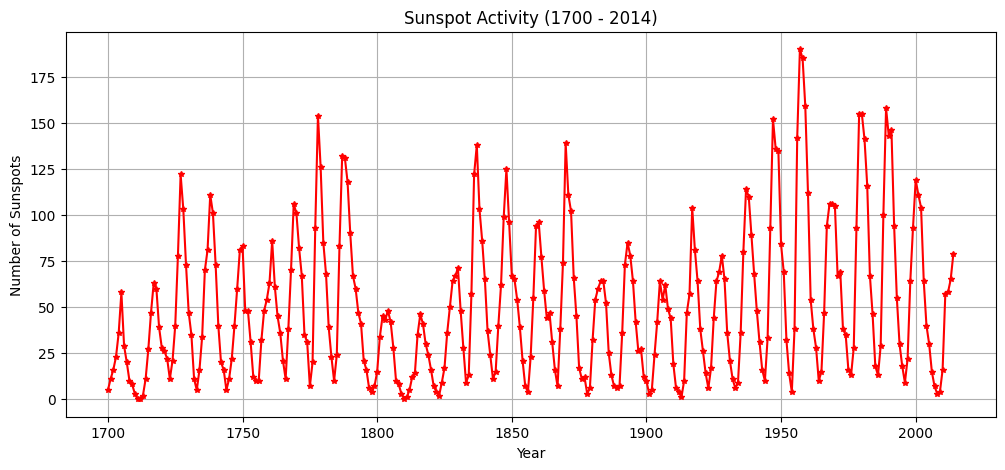

In [50]:
# Task 4: Plot sunspot activity diagram with fully labelled axes
plt.figure(figsize=(12, 5))
plt.plot(years, sunspots, 'r-*', markersize=4)
plt.title('Sunspot Activity (1700 - 2014)')
plt.xlabel('Year')
plt.ylabel('Number of Sunspots')
plt.grid(True)
plt.show()

In [51]:
# Task 5: Build input matrix P and output vector T for model order N=2
def create_dataset(series, n):
    X, Y = [], []
    for i in range(len(series) - n):
        X.append(series[i:i+n])
        Y.append(series[i+n])
    return np.array(X), np.array(Y)

N = 2
X, Y = create_dataset(sunspots, N)

print(f"P (input matrix) shape:  {X.shape}")
print(f"T (output vector) shape: {Y.shape}")

P (input matrix) shape:  (313, 2)
T (output vector) shape: (313,)


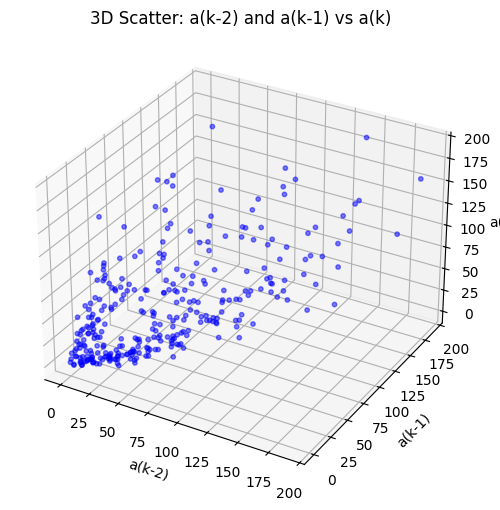

In [52]:
# Task 6: 3D plot of inputs a(k-2), a(k-1) vs target a(k)
# Graphical interpretation:
#   w1, w2 = slopes (tilt) of the regression plane along each input axis
#   b      = intercept where the plane crosses the z-axis (both inputs = 0)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], Y, c='blue', alpha=0.5, s=10)
ax.set_title('3D Scatter: a(k-2) and a(k-1) vs a(k)')
ax.set_xlabel('a(k-2)')
ax.set_ylabel('a(k-1)')
ax.set_zlabel('a(k)')
plt.show()

In [53]:
# Task 7: Split into training (first 200) and test (remaining) sets
X_train, Y_train = X[:200], Y[:200]
X_test,  Y_test  = X[200:], Y[200:]
test_years = years[N + 200:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 200
Test samples:     113


In [54]:
# Tasks 8-9: Train analytical model using matrix calculus (newlind equivalent)
# and display weight coefficients
model_ana = LinearRegression().fit(X_train, Y_train)

print("=== Analytical Model Weights (N=2) ===")
print(f"w1: {model_ana.coef_[0]:.4f}")
print(f"w2: {model_ana.coef_[1]:.4f}")
print(f"b:  {model_ana.intercept_:.4f}")

=== Analytical Model Weights (N=2) ===
w1: -0.6761
w2: 1.3715
b:  13.4037


In [55]:
# Tasks 16-19: Train iterative model (newlin equivalent) and display weights
# A very small learning rate is required to prevent divergence
model_iter = SGDRegressor(learning_rate='constant', eta0=1e-6, max_iter=2000)
model_iter.fit(X_train, Y_train)

print("=== Iterative Model Weights (N=2) ===")
print(f"w1: {model_iter.coef_[0]:.4f}")
print(f"w2: {model_iter.coef_[1]:.4f}")
print(f"b:  {model_iter.intercept_[0]:.4f}")

=== Iterative Model Weights (N=2) ===
w1: -0.5304
w2: 1.4146
b:  0.0718


In [56]:
# Task 20: Find the maximum learning rate that still allows convergence
learning_rates = [1e-6, 5e-6, 1e-5, 5e-5, 1e-4]

print("Learning Rate Convergence Investigation (N=2)")
print("-" * 48)
for lr in learning_rates:
    m = SGDRegressor(learning_rate='constant', eta0=lr, max_iter=2000)
    m.fit(X_train, Y_train)
    preds = m.predict(X_test)
    mse = mean_squared_error(Y_test, preds)
    status = "DIVERGED" if mse > 100000 else "converged"
    print(f"eta0 = {lr:.0e}  ->  MSE: {mse:>12.2f}  [{status}]")

Learning Rate Convergence Investigation (N=2)
------------------------------------------------
eta0 = 1e-06  ->  MSE:       495.93  [converged]
eta0 = 5e-06  ->  MSE:       495.47  [converged]
eta0 = 1e-05  ->  MSE:       508.39  [converged]
eta0 = 5e-05  ->  MSE:      1927.82  [converged]
eta0 = 1e-04  ->  MSE:       601.31  [converged]


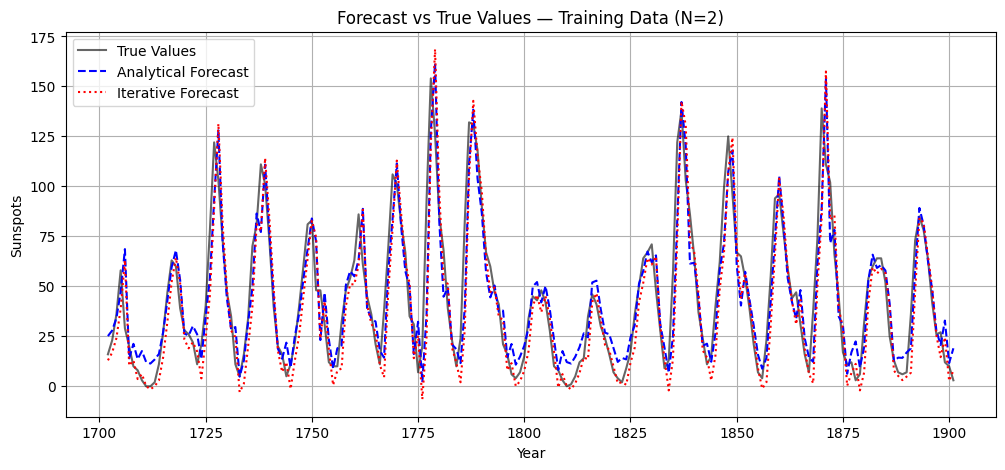

In [57]:
# Task 10: Simulate model on training data and compare to true values
train_years = years[N:N + 200]
Y_pred_ana_train  = model_ana.predict(X_train)
Y_pred_iter_train = model_iter.predict(X_train)

plt.figure(figsize=(12, 5))
plt.plot(train_years, Y_train, 'k-', label='True Values', alpha=0.6)
plt.plot(train_years, Y_pred_ana_train, 'b--', label='Analytical Forecast')
plt.plot(train_years, Y_pred_iter_train, 'r:', label='Iterative Forecast')
plt.title('Forecast vs True Values — Training Data (N=2)')
plt.xlabel('Year')
plt.ylabel('Sunspots')
plt.legend()
plt.grid(True)
plt.show()


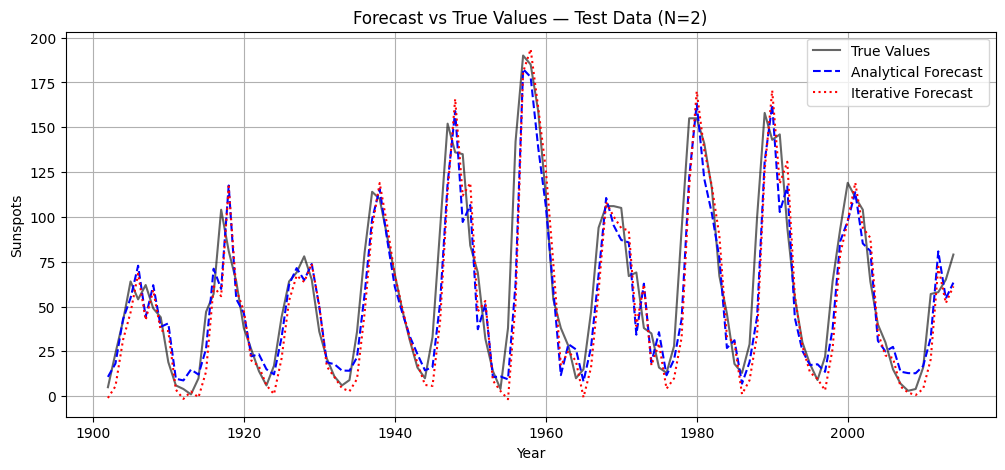

In [58]:
# Task 11: Simulate model on test data and compare to true values
Y_pred_ana  = model_ana.predict(X_test)
Y_pred_iter = model_iter.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(test_years, Y_test, 'k-', label='True Values', alpha=0.6)
plt.plot(test_years, Y_pred_ana, 'b--', label='Analytical Forecast')
plt.plot(test_years, Y_pred_iter, 'r:', label='Iterative Forecast')
plt.title('Forecast vs True Values — Test Data (N=2)')
plt.xlabel('Year')
plt.ylabel('Sunspots')
plt.legend()
plt.grid(True)
plt.show()

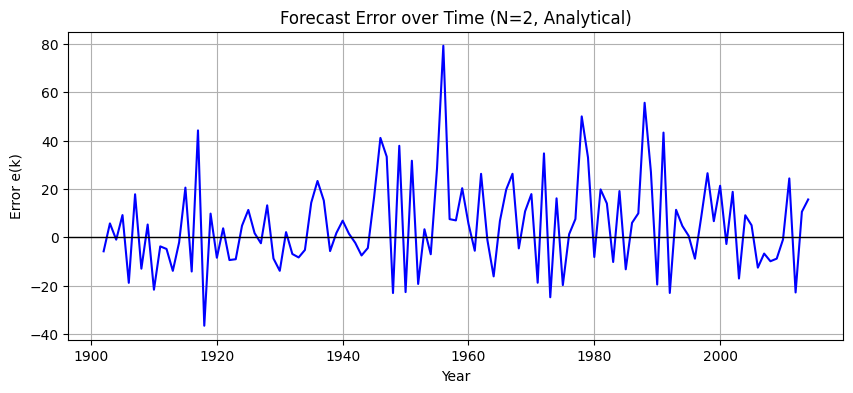

In [59]:
# Task 12: Compute forecast error vector and plot over time
errors = Y_test - Y_pred_ana

plt.figure(figsize=(10, 4))
plt.plot(test_years, errors, color='blue')
plt.axhline(0, color='black', linewidth=1)
plt.title('Forecast Error over Time (N=2, Analytical)')
plt.xlabel('Year')
plt.ylabel('Error e(k)')
plt.grid(True)
plt.show()

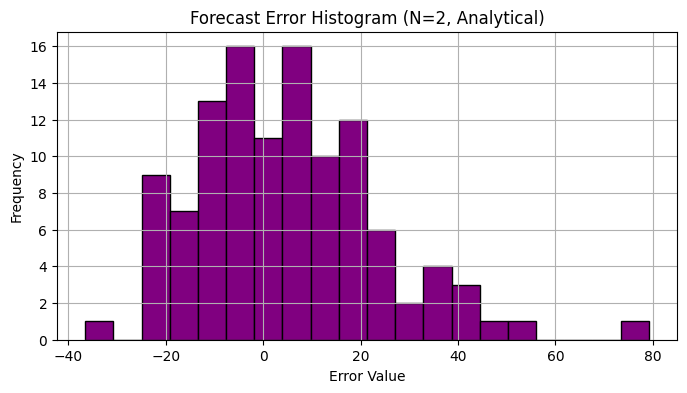

In [60]:
# Task 13: Plot forecast error histogram
plt.figure(figsize=(8, 4))
plt.hist(errors, bins=20, color='purple', edgecolor='black')
plt.title('Forecast Error Histogram (N=2, Analytical)')
plt.xlabel('Error Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [61]:
# Task 14: Calculate MSE and MAD for both models on test data
mse_ana  = mean_squared_error(Y_test, Y_pred_ana)
mad_ana  = np.median(np.abs(Y_test - Y_pred_ana))
mse_iter = mean_squared_error(Y_test, Y_pred_iter)
mad_iter = np.median(np.abs(Y_test - Y_pred_iter))

print("=== Error Metrics (N=2, Test Data) ===")
print(f"Analytical -> MSE: {mse_ana:.4f},  MAD: {mad_ana:.4f}")
print(f"Iterative  -> MSE: {mse_iter:.4f},  MAD: {mad_iter:.4f}")

=== Error Metrics (N=2, Test Data) ===
Analytical -> MSE: 386.4042,  MAD: 10.7680
Iterative  -> MSE: 497.3032,  MAD: 12.6808


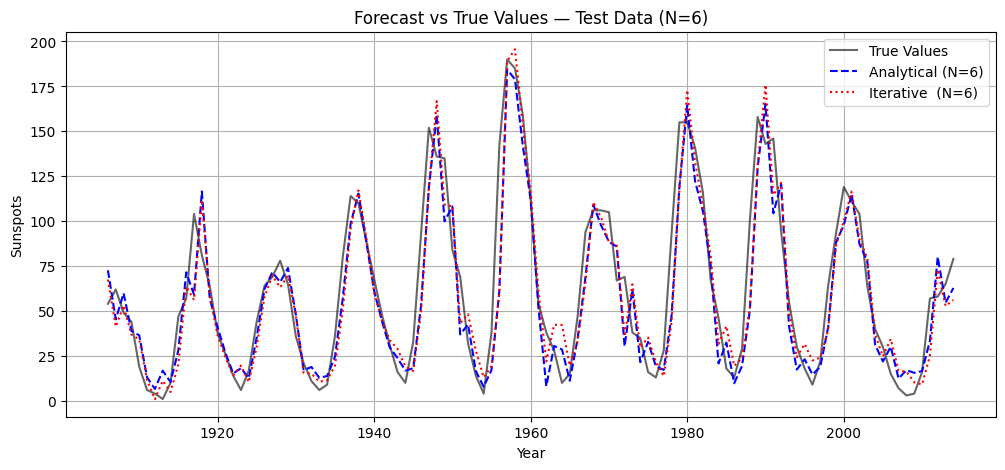

N=6 | Analytical -> MSE: 381.0138,  MAD: 11.5940
N=6 | Iterative  -> MSE: 396.3315,  MAD: 13.4402
----------------------------------------------------


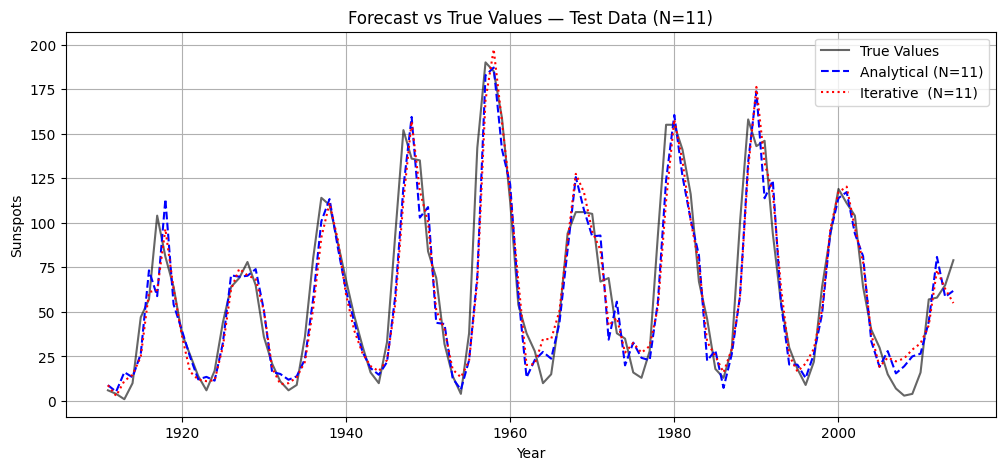

N=11 | Analytical -> MSE: 321.7555,  MAD: 10.4721
N=11 | Iterative  -> MSE: 307.5184,  MAD: 9.6467
----------------------------------------------------


In [67]:
# Task 21 (Mandatory): Repeat all experiments for N=6 and N=11
# using BOTH analytical and iterative methods

for n_val in [6, 11]:
    X_v, Y_v = create_dataset(sunspots, n_val)
    X_tr, Y_tr = X_v[:200], Y_v[:200]
    X_ts, Y_ts = X_v[200:], Y_v[200:]
    t_years = years[n_val + 200:]

    # Analytical
    m_ana = LinearRegression().fit(X_tr, Y_tr)
    preds_ana = m_ana.predict(X_ts)

    # Iterative
    m_iter = SGDRegressor(learning_rate='constant', eta0=1e-6, max_iter=2000)
    m_iter.fit(X_tr, Y_tr)
    preds_iter = m_iter.predict(X_ts)

    # Forecast comparison plot
    plt.figure(figsize=(12, 5))
    plt.plot(t_years, Y_ts, 'k-', label='True Values', alpha=0.6)
    plt.plot(t_years, preds_ana,  'b--', label=f'Analytical (N={n_val})')
    plt.plot(t_years, preds_iter, 'r:',  label=f'Iterative  (N={n_val})')
    plt.title(f'Forecast vs True Values — Test Data (N={n_val})')
    plt.xlabel('Year')
    plt.ylabel('Sunspots')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Error metrics
    mse_ana  = mean_squared_error(Y_ts, preds_ana)
    mad_ana  = np.median(np.abs(Y_ts - preds_ana))
    mse_iter = mean_squared_error(Y_ts, preds_iter)
    mad_iter = np.median(np.abs(Y_ts - preds_iter))

    print(f"N={n_val} | Analytical -> MSE: {mse_ana:.4f},  MAD: {mad_ana:.4f}")
    print(f"N={n_val} | Iterative  -> MSE: {mse_iter:.4f},  MAD: {mad_iter:.4f}")
    print("-" * 52)